In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.stats import sigma_clip
import json
import pandas as pd 
import os
import copy
from scipy.ndimage import label, find_objects
from scipy.spatial.distance import euclidean
import cv2

def map_coordinate_with_pixel(fits_file, target_ra, target_dec, host_ra, host_dec, image_type = 'd'):

    # Load the FITS file
    hdul = fits.open(fits_file)
    if not fits_file.endswith('.fits.fz'):
        data = hdul[0].data
        header = hdul[0].header
    else:
        data = hdul[1].data
        header = hdul[1].header
    
    wcs = WCS(header)

    # Convert RA and DEC to pixel coordinates, find the target pixels
    target_coords = SkyCoord(ra=target_ra, dec=target_dec, unit="deg")
    pixel_coords_target = target_coords.to_pixel(wcs)

    # Convert RA and DEC to pixel coordinates, find the host pixels
    if host_ra is not None and host_dec is not None: 
        host_coords = SkyCoord(ra=host_ra, dec=host_dec, unit="deg")
        pixel_coords_host = host_coords.to_pixel(wcs)
        if image_type == 'd': # science image
            pixel_coords_host = [float(pixel_coords_host[0]), float(header['NAXIS2'] - pixel_coords_host[1])]
        else:
            pixel_coords_host = [float(header['NAXIS1'] - pixel_coords_host[0]), float(header['NAXIS2'] - pixel_coords_host[1])]
    else:
        pixel_coords_host = None 
        
    print('host pixel: ', pixel_coords_host)

    # Plot the image
    fig, ax = plt.subplots(subplot_kw={'projection': wcs})
    img_norm = ImageNormalize(data, interval=ZScaleInterval())
    ax.imshow(data, cmap='gray', norm=img_norm)
    ax.set_title('original')
    # ax.set_xlabel('RA')
    # ax.set_ylabel('DEC')
    ax.set_axis_off()

    # Mark the target coordinates
    ax.plot(pixel_coords_target[0], pixel_coords_target[1], marker='o', color='red', markersize=5, label= 'target RA/DEC')
    ax.plot(data.shape[0]/2, data.shape[1]/2, marker='o', color='green', markersize=5, label= 'image centre')
    if pixel_coords_host is not None: 
        ax.plot(pixel_coords_host[0], pixel_coords_host[1], marker='o', color='blue', markersize=5, label= 'host RA/DEC')
    ax.legend()

    # Show the plot
    plt.show()

    # Close the FITS file
    hdul.close()

    masked_img, mask1, final_mask, hashost, reach_edge = plot_pixel_distribution(data, wcs, pixel_coords_host, pixel_coords_target, img_norm)
    

def get_host_coords(host_path):
    if os.path.exists(host_path):
        host_data = pd.read_csv(host_path)
        host_ra, host_dec = host_data['ra'][0], host_data['dec'][0]
        del host_data
        return float(host_ra), float(host_dec)
    else:
        return None, None

def get_target_coords(target_path):
    m = open(target_path, 'r')
    jfile = json.loads(m.read())
    return jfile["objectData"]['ramean'], jfile["objectData"]['decmean']

def get_detection_with_mag(meta_path):
    m = open(meta_path, 'r')
    jfile = json.loads(m.read())
    return jfile["f2"]["withMag"]

def change_axis(wcs, label):
     # Make a copy of the original WCS to modify
    
    new_wcs = copy.deepcopy(wcs)
    
    # Flip the DEC axis by multiplying the relevant WCS matrix elements by -1
 
    new_wcs.wcs.cd[1, :] *= -1  # Flip the sign of the second row
    if label != 'd': 
        new_wcs.wcs.cd[:, 1] *= -1  
    print(new_wcs.wcs.cd)
    return new_wcs


def plot_pixel_distribution(data, wcs, host_pixels, target_pixels, img_norm): 

    hashost = True 
    if host_pixels is not None: 
        host_x, host_y = host_pixels
        host_x, host_y = int(host_x), int(host_y)
    else:
        hashost = False
    
    tar_x, tar_y = target_pixels
    tar_x, tar_y = int(tar_x), int(tar_y)
    
    plt.figure(figsize=(5,5))
    clipped_data = sigma_clip(data, sigma = 2, maxiters= 10)
    mask1 = data - clipped_data

    # Ensure mask1 is binary before processing
    mask1 = (mask1 > 0).astype(np.uint8)

    # Label connected components
    labels, num_features = label(mask1)

    # Find bounding boxes for each labeled region
    regions = find_objects(labels)

    # Extract the centroid for each labeled region
    if regions:
        centroids = np.array([[(r[0].start + r[0].stop - 1) // 2, 
                            (r[1].start + r[1].stop - 1) // 2] for r in regions])
    else:
        centroids = np.array([])

    fig, ax = plt.subplots(subplot_kw={'projection': wcs})
    ax.imshow(mask1, cmap='gray')
    ax.scatter(centroids[:,1],centroids[:,0], color = 'red')
    ax.set_title('mask1')
    ax.set_axis_off()
    plt.show()

    # Label connected components
    labeled_mask, _ = label(mask1)

    # Identify which label contains host and transient clusters
    if hashost: 
        host_label = labeled_mask[host_y, host_x]
        host_pixels = np.array(np.where(labeled_mask == host_label))
    else:
        host_label = None
        host_pixels = None
    transient_label = labeled_mask[tar_y, tar_x]
    transient_pixels = np.array(np.where(labeled_mask == transient_label))

    final_mask = np.zeros_like(data)
    
    
    # Set the specified (x, y) coordinates to 1
    for x, y in transient_pixels.T:
        if 0 <= x < mask1.shape[0] and 0 <= y < mask1.shape[1]:  # Ensure coordinates are within bounds
            final_mask[x, y] = 1


    reach_edge = False
    if hashost:
        for x, y in host_pixels.T:
            if 0 <= x < mask1.shape[0] and 0 <= y < mask1.shape[1]:  # Ensure coordinates are within bounds
                final_mask[x, y] = 1
            if x==0 or y==0 or x==60 or y == 60:
                reach_edge = True  # host pixels reach to the boundaries.

    # Display the final mask
    fig, ax = plt.subplots(subplot_kw={'projection': wcs})
    ax.imshow(final_mask, cmap='gray')
    ax.set_title('mask2')
    ax.set_axis_off()
    plt.show()
    
    # Apply mask to data: 1. only remain host and transients, others are dark; 2. only remain host and transients, and other are noise
    masked_img = data * final_mask  # This keeps only the masked regions

    fig, ax = plt.subplots(subplot_kw={'projection': wcs})
    ax.imshow(masked_img, cmap='gray', norm = img_norm)
    ax.set_title('masked image')
    ax.set_axis_off()
    plt.show()

    return masked_img, mask1, final_mask, hashost, reach_edge
    

                
def display(orgin_img, mask1, mask2, host_region, target_region):
    pass  

    

    

host coords: 159.69108062, 53.50342, transient_coords: 159.696817375, 53.5084008
host pixel:  [41.7702420518198, 12.333458046507587]


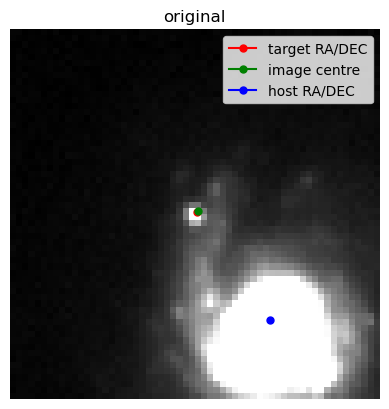

<Figure size 500x500 with 0 Axes>

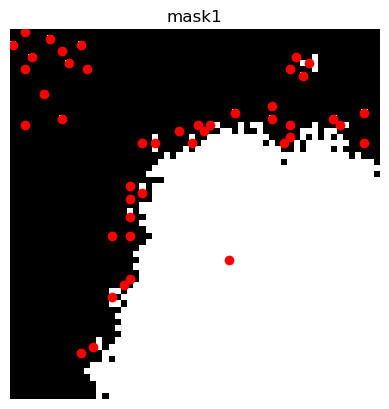

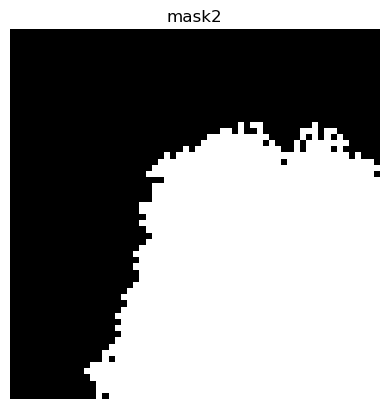

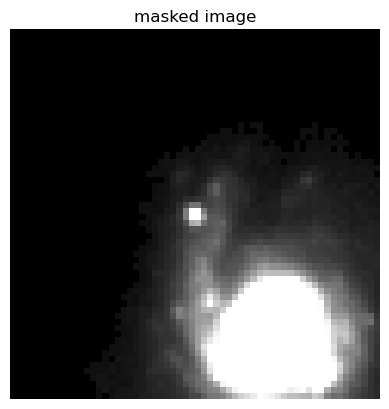

host pixel:  [42.20929548903902, 12.846225795319867]


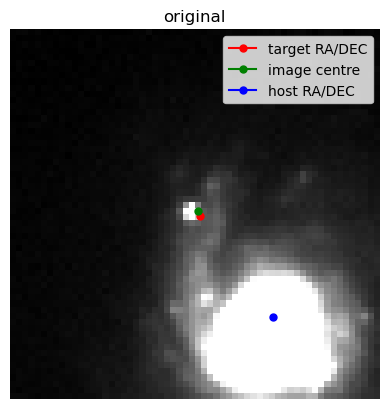

<Figure size 500x500 with 0 Axes>

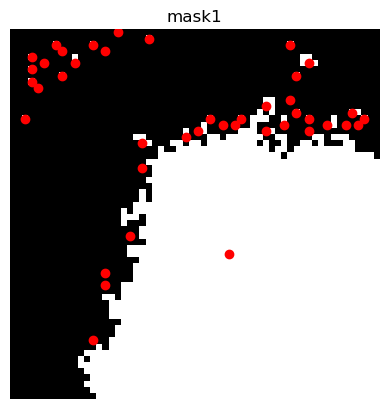

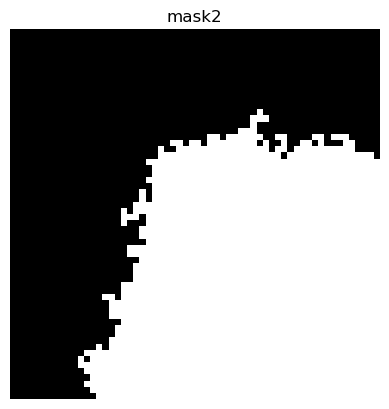

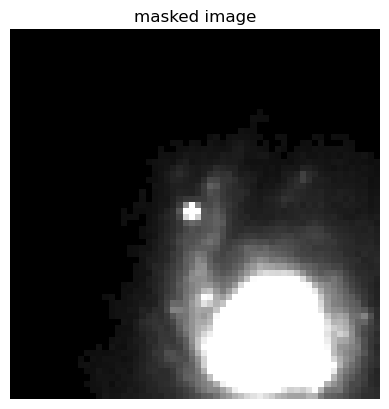

host pixel:  [41.623541808380025, 11.959210925856837]


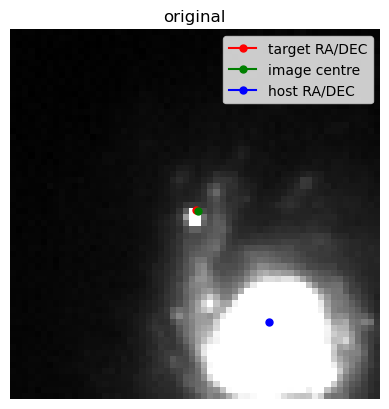

<Figure size 500x500 with 0 Axes>

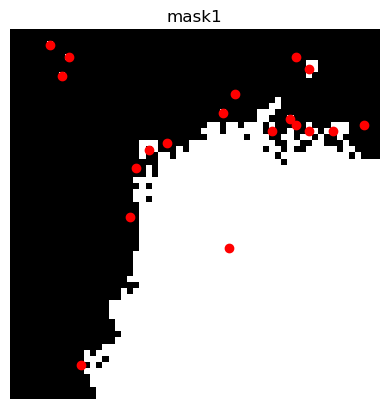

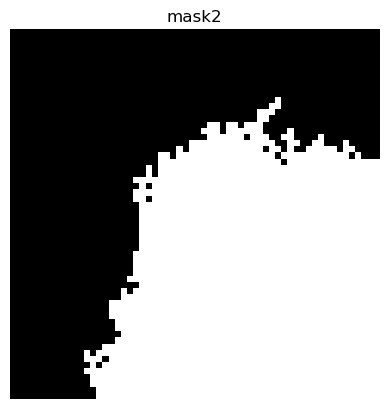

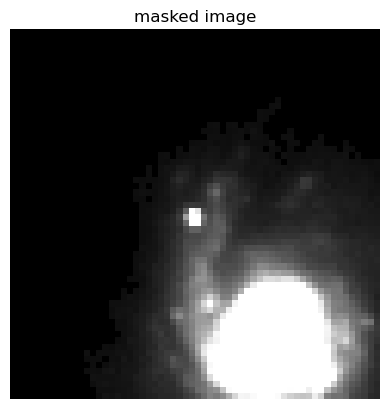

host pixel:  [41.414161326686475, 12.276469649646657]


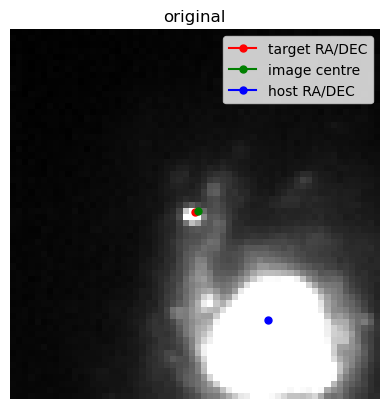

<Figure size 500x500 with 0 Axes>

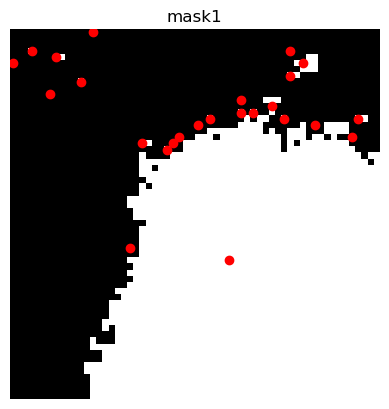

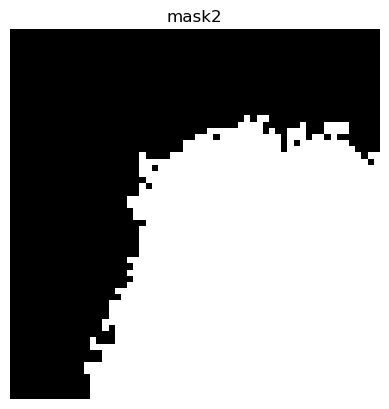

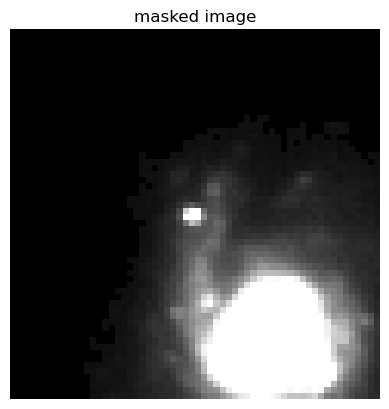

host pixel:  [41.7539972532574, 12.798431156667306]


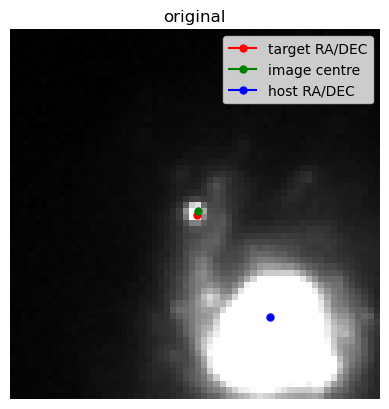

<Figure size 500x500 with 0 Axes>

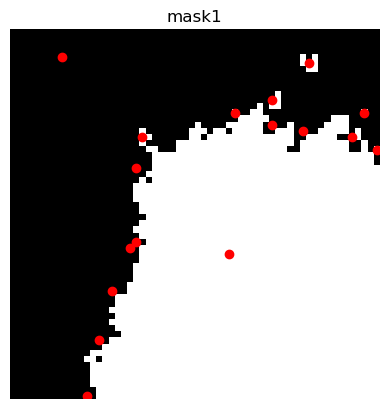

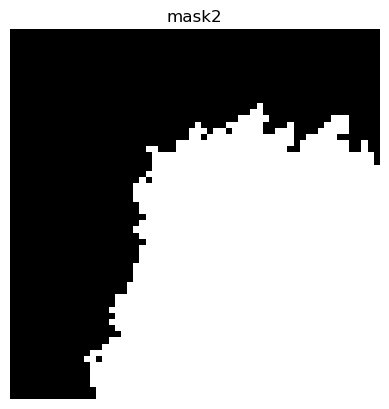

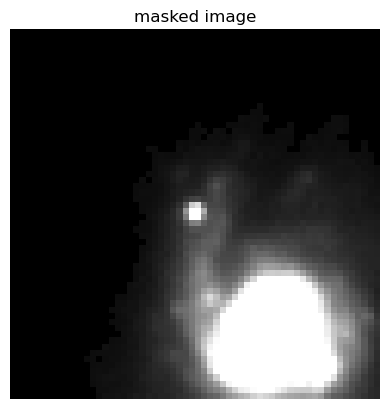

host pixel:  [41.65677781960483, 11.936352849845008]


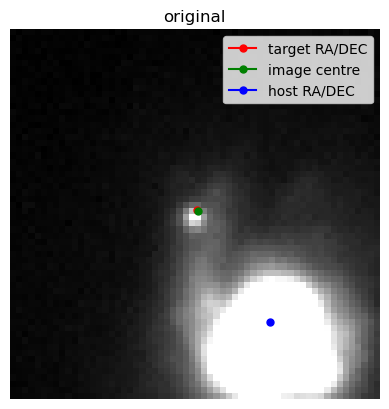

<Figure size 500x500 with 0 Axes>

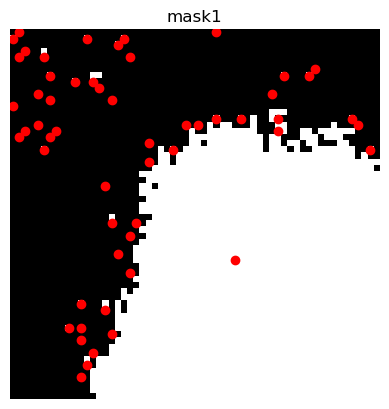

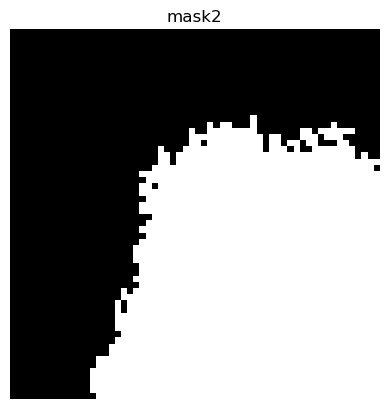

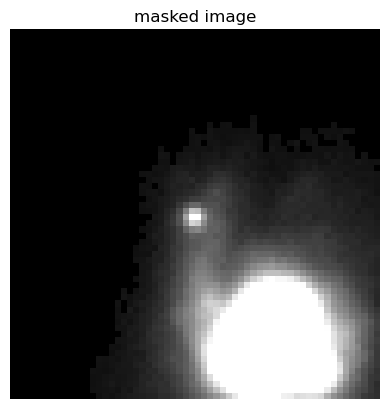

host pixel:  [41.64654119046006, 12.726626160682997]


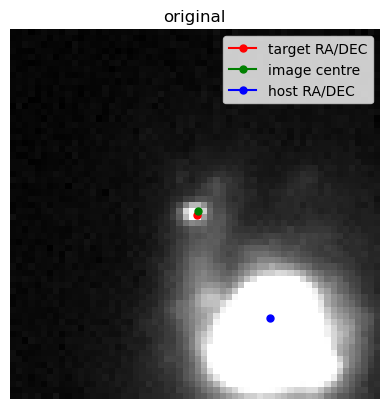

<Figure size 500x500 with 0 Axes>

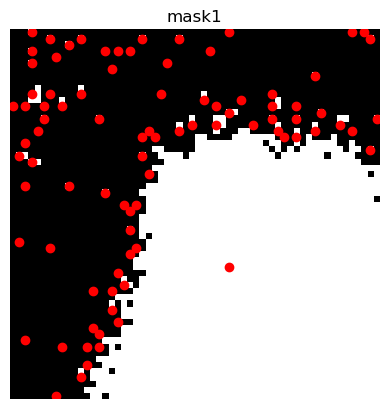

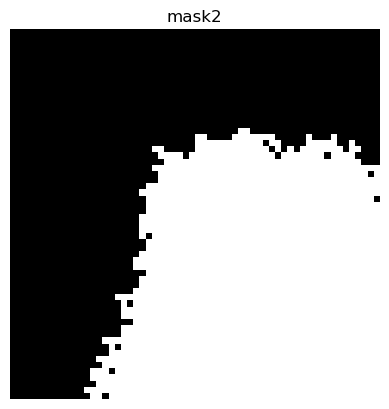

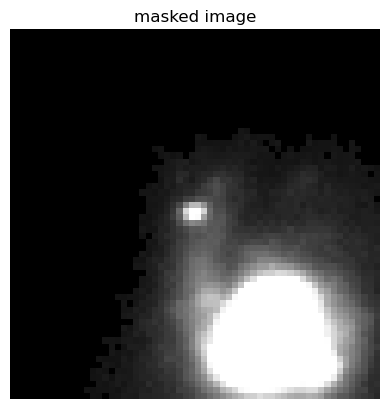

host pixel:  [42.13645385119234, 12.867052823808706]


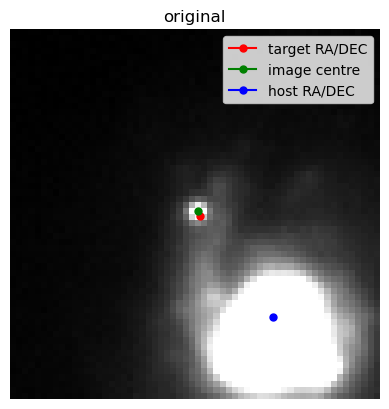

<Figure size 500x500 with 0 Axes>

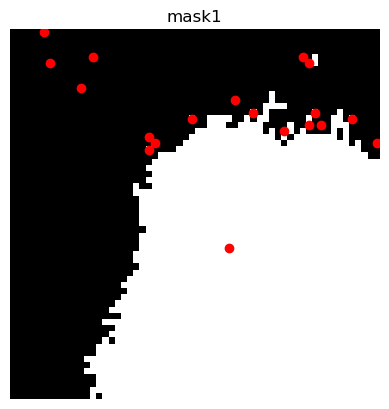

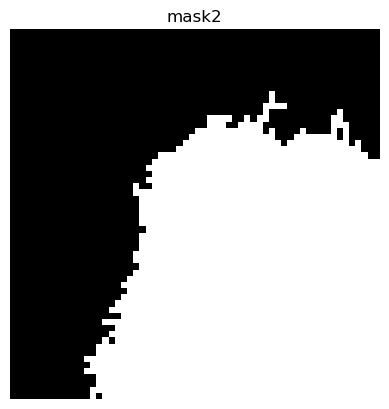

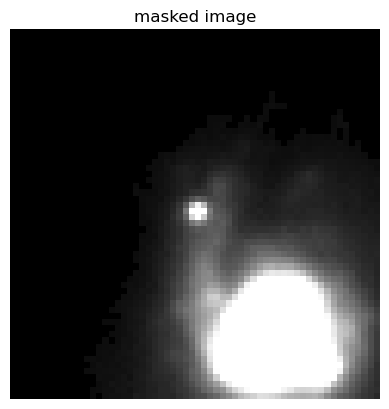

host pixel:  [41.37524037731961, 12.615057381504784]


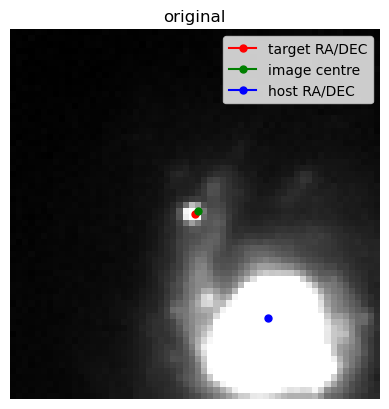

<Figure size 500x500 with 0 Axes>

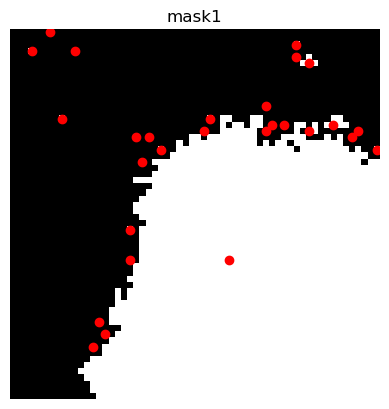

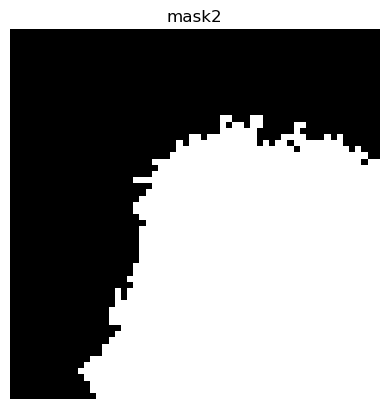

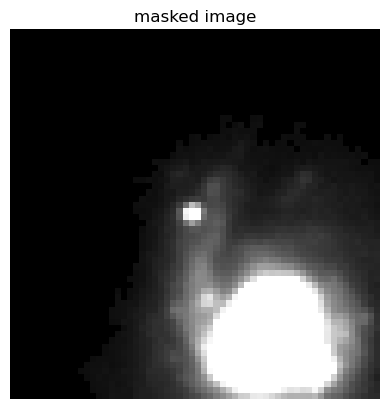

host pixel:  [42.09495550036137, 11.995429080642253]


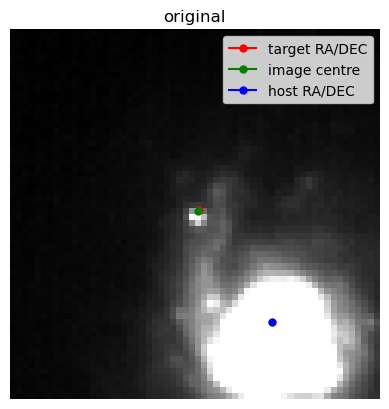

<Figure size 500x500 with 0 Axes>

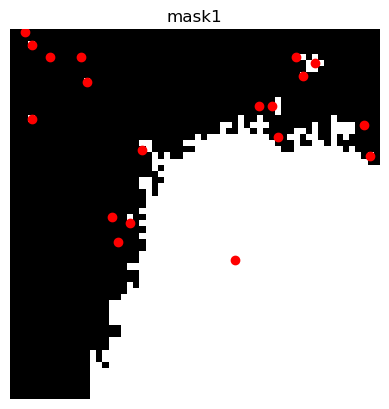

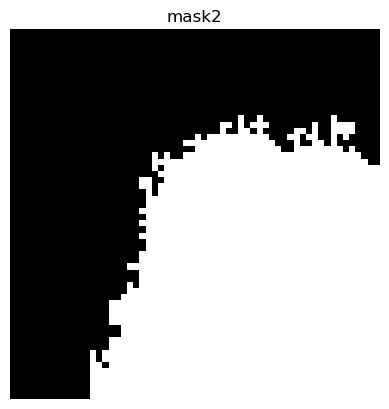

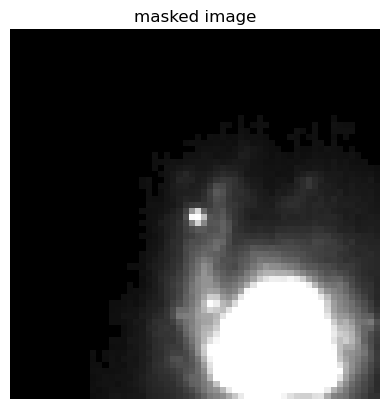

host pixel:  [41.46714685305862, 12.318206965061222]


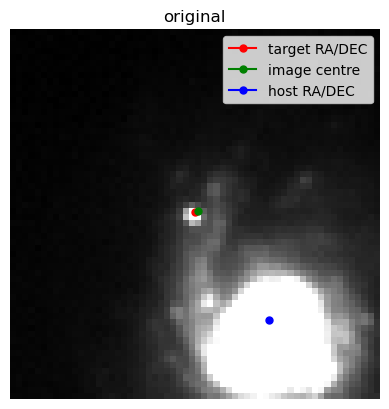

<Figure size 500x500 with 0 Axes>

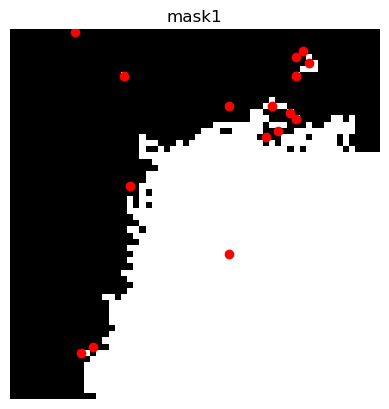

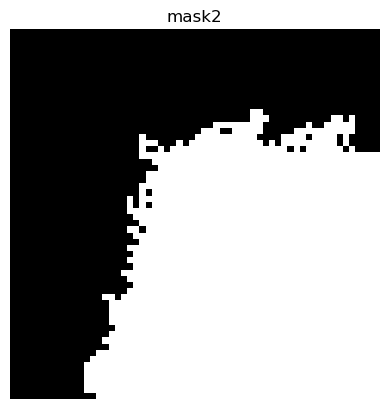

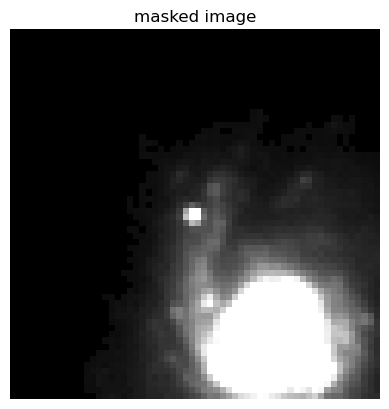

host pixel:  [41.390905249598596, 12.090928450085585]


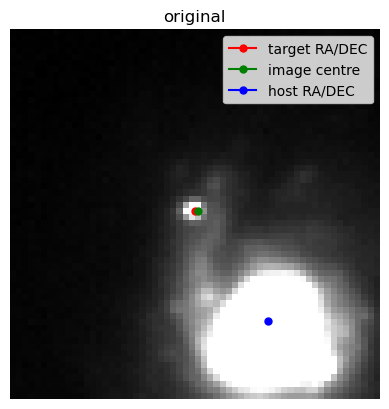

<Figure size 500x500 with 0 Axes>

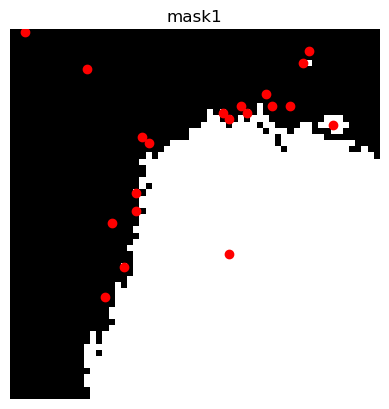

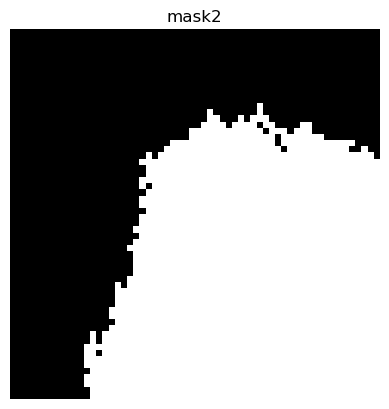

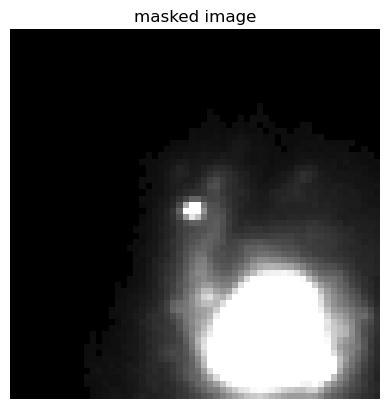

host pixel:  [41.74852641988859, 12.370907253819723]


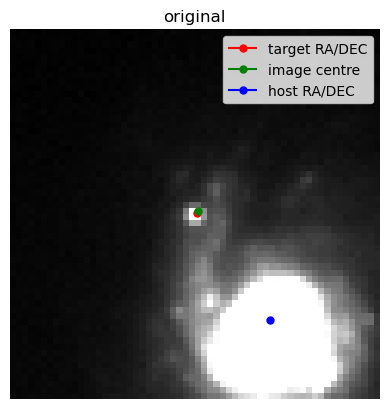

<Figure size 500x500 with 0 Axes>

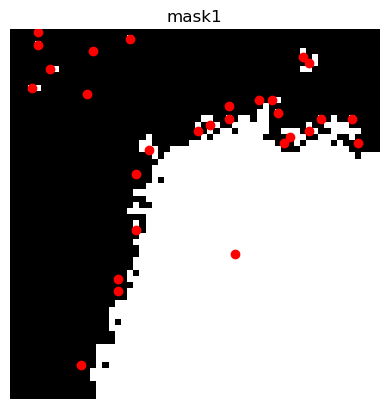

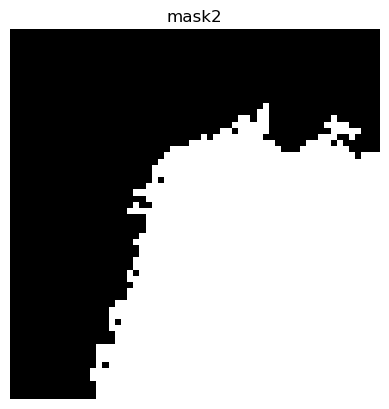

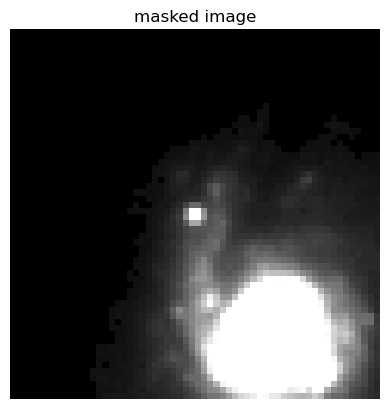

host pixel:  [41.377499655464874, 12.497843435860688]


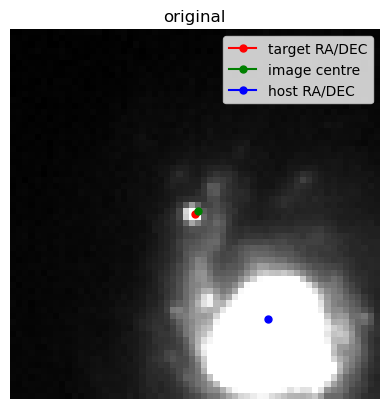

<Figure size 500x500 with 0 Axes>

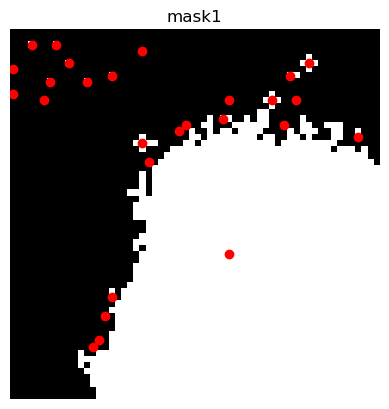

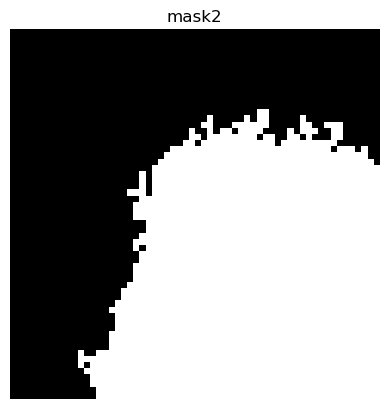

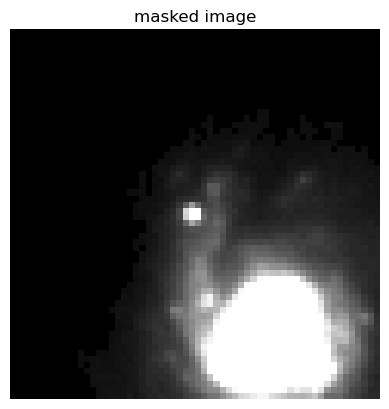

host pixel:  [41.66514442747468, 12.571042397080078]


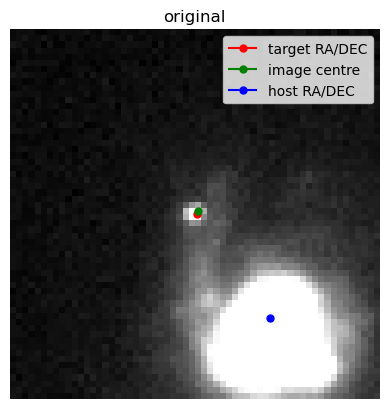

<Figure size 500x500 with 0 Axes>

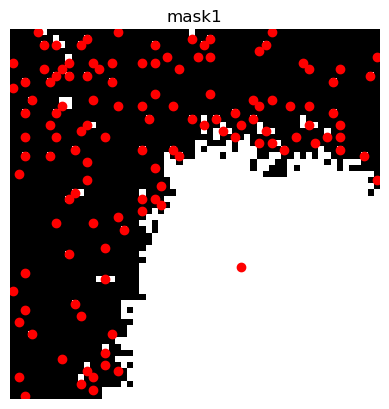

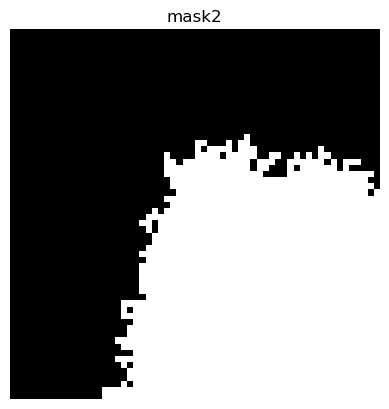

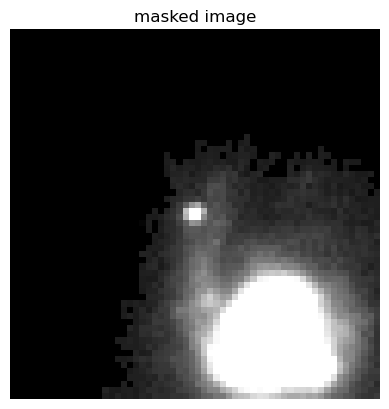

host pixel:  [42.1427770724779, 12.285445962435261]


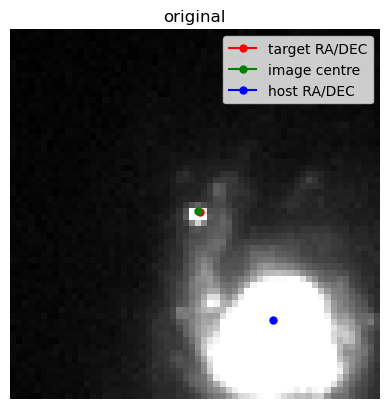

<Figure size 500x500 with 0 Axes>

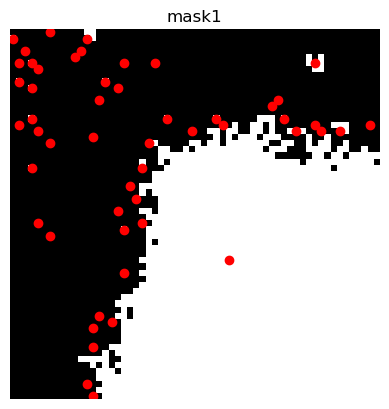

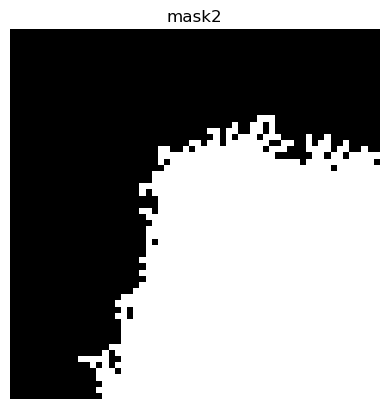

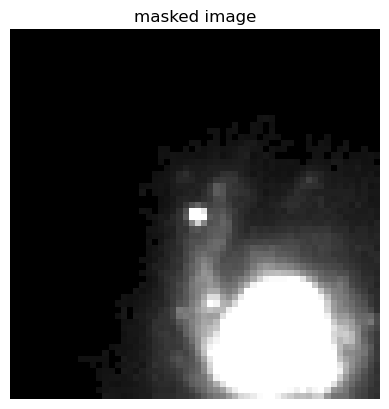

host pixel:  [41.84190832908087, 12.529364983615409]


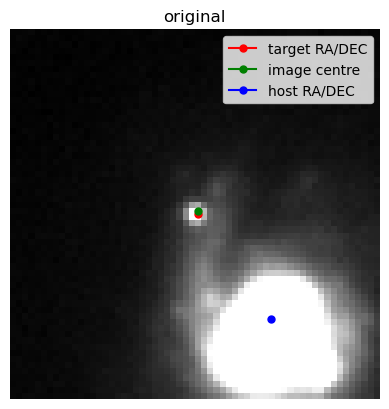

<Figure size 500x500 with 0 Axes>

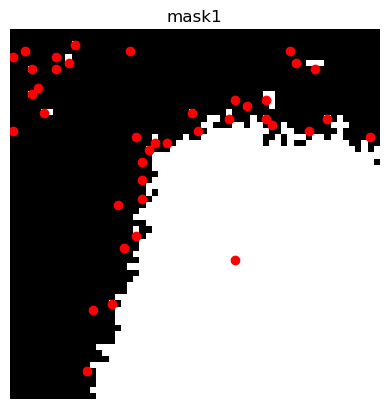

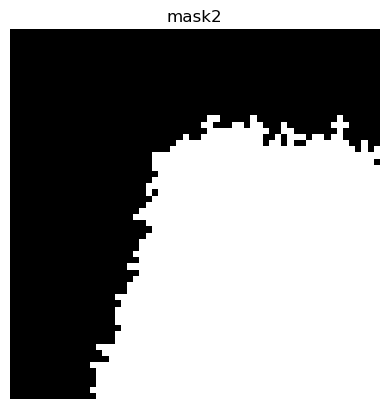

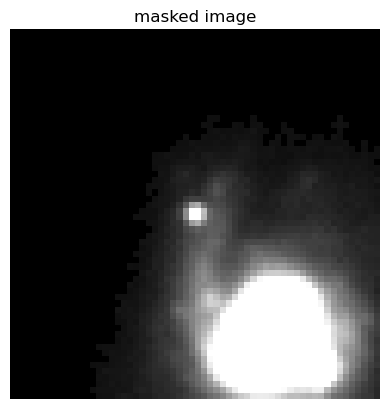

host pixel:  [41.56932229042629, 12.606735704668239]


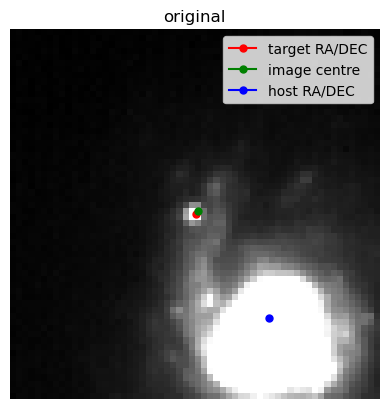

<Figure size 500x500 with 0 Axes>

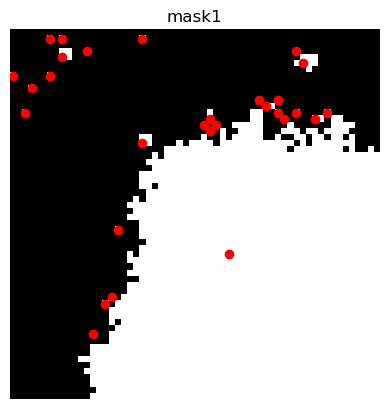

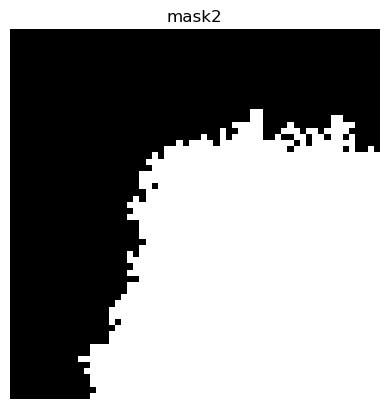

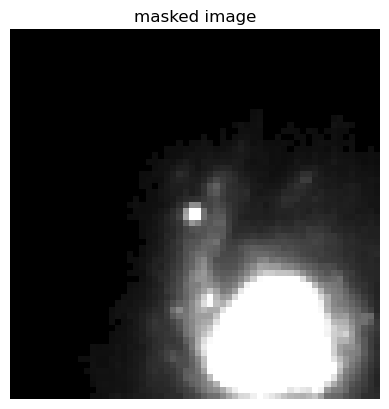

host pixel:  [41.48435698205934, 11.92805177424728]


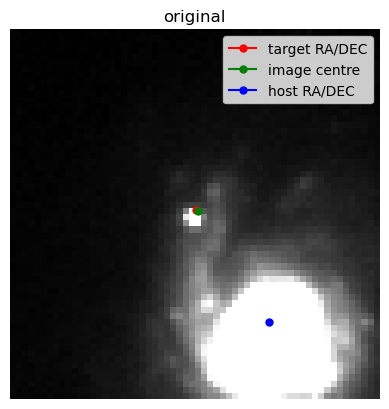

<Figure size 500x500 with 0 Axes>

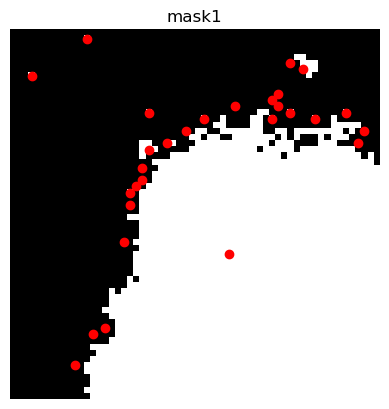

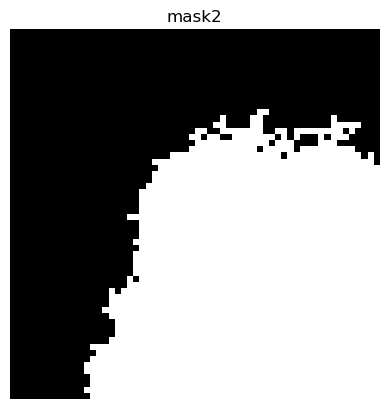

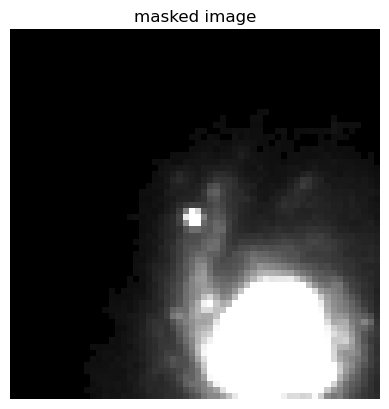

host pixel:  [42.20217034176049, 12.887245571305385]


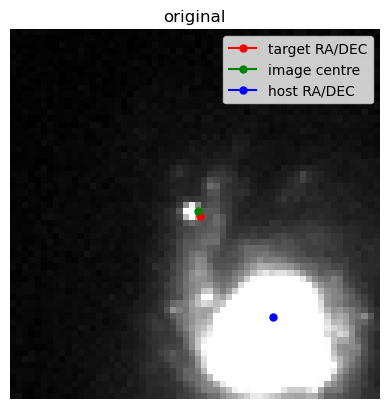

<Figure size 500x500 with 0 Axes>

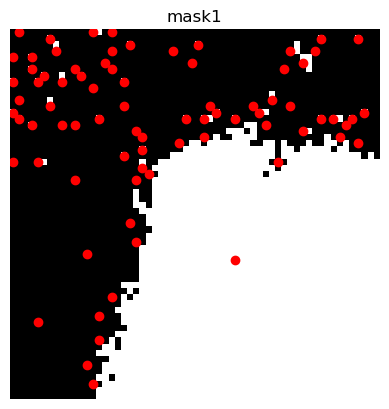

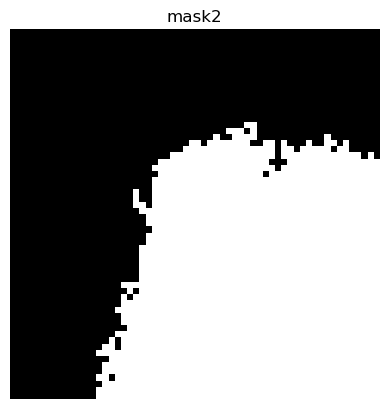

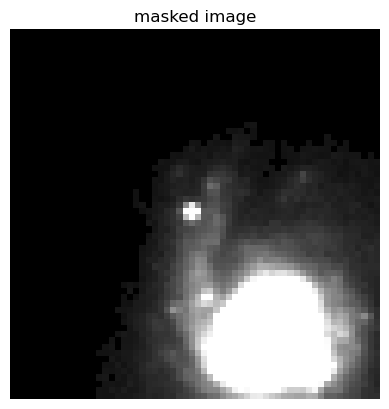

host pixel:  [41.556517378885104, 12.152333440921865]


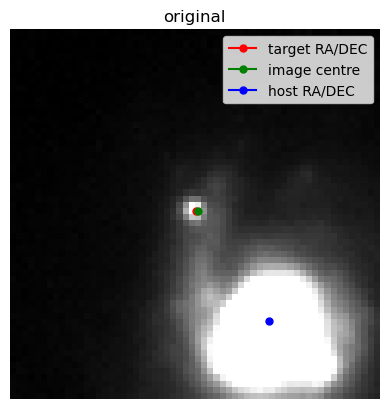

<Figure size 500x500 with 0 Axes>

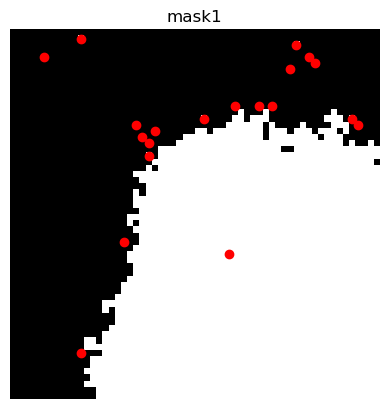

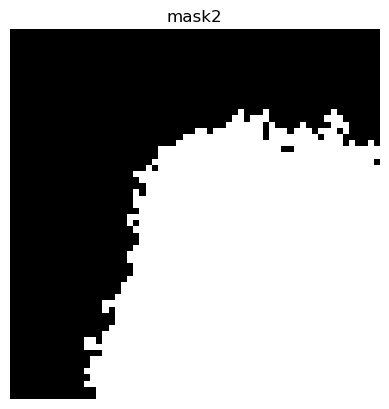

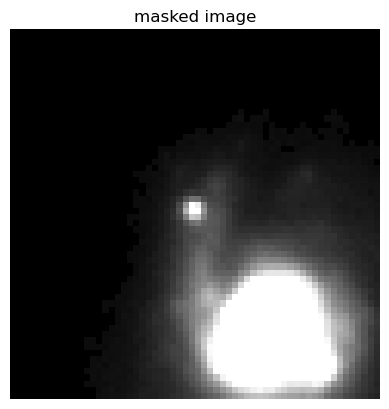

host pixel:  [41.93972867377613, 12.265802773565838]


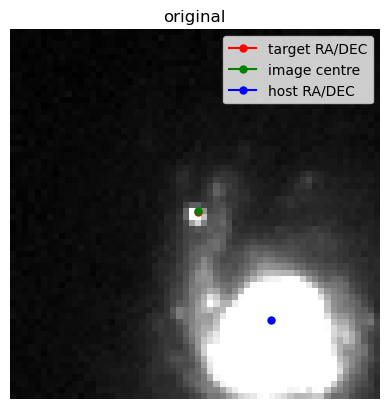

<Figure size 500x500 with 0 Axes>

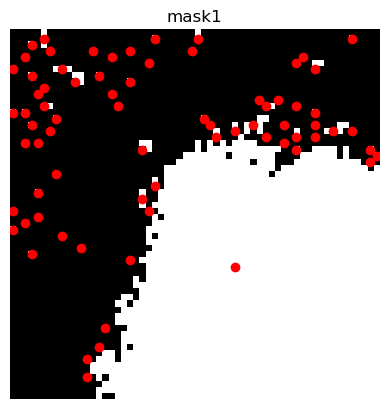

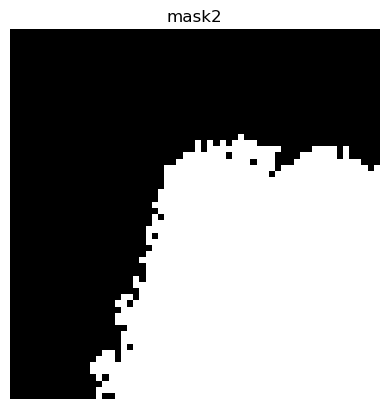

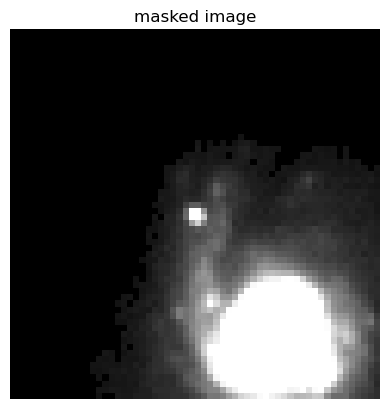

host pixel:  [41.293193434433626, 12.001987430955722]


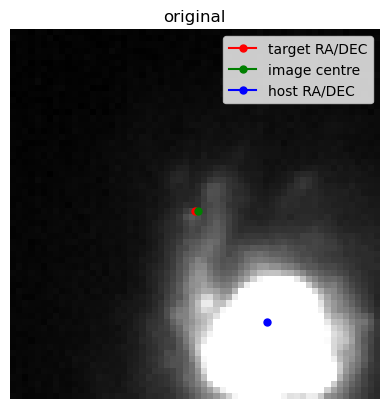

<Figure size 500x500 with 0 Axes>

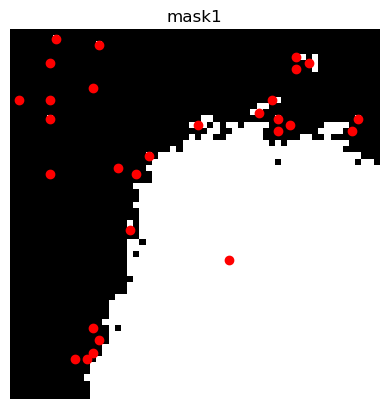

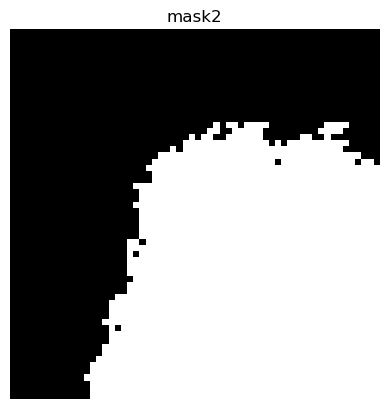

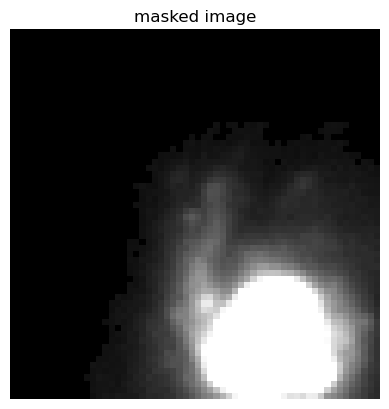

host pixel:  [41.79404266338743, 12.687582505093275]


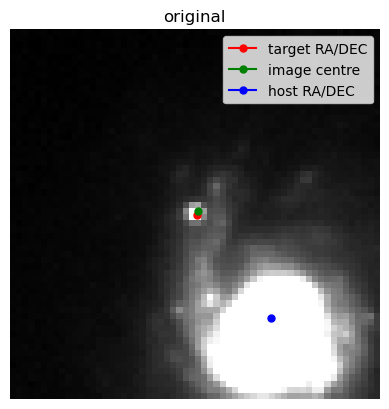

<Figure size 500x500 with 0 Axes>

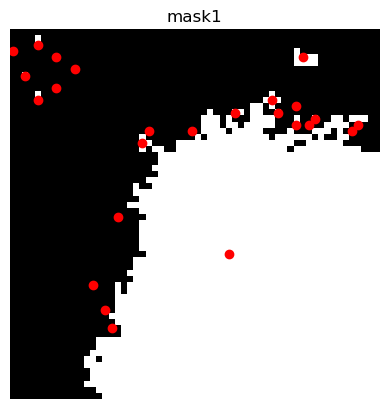

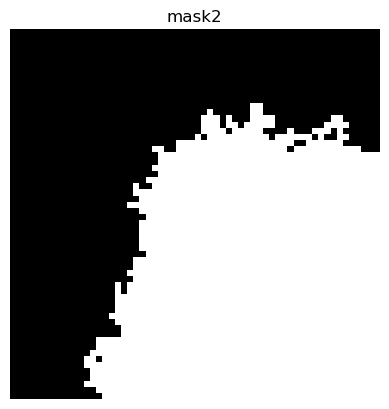

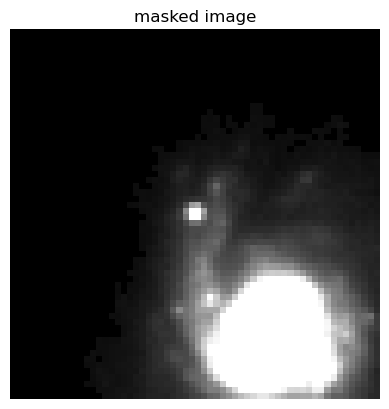

host pixel:  [41.93089524047052, 12.680896991897015]


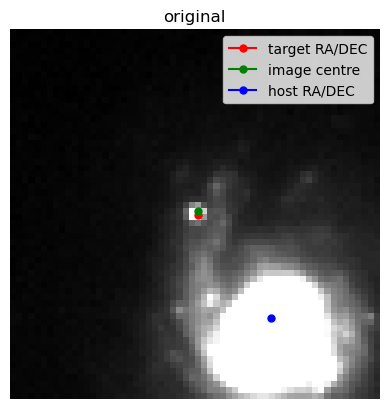

<Figure size 500x500 with 0 Axes>

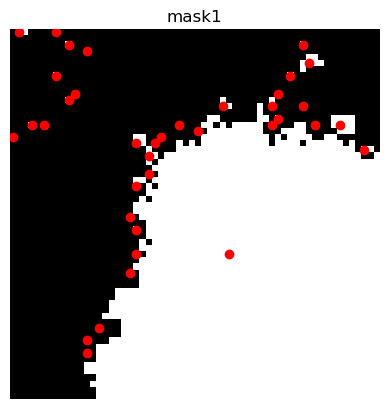

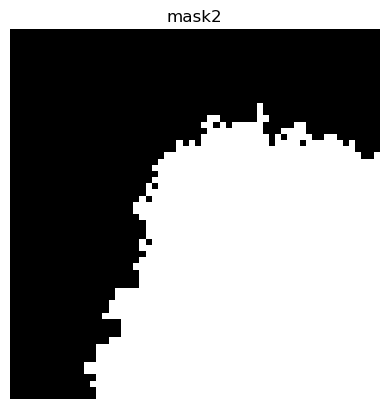

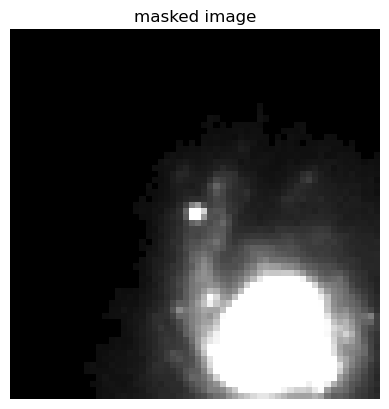

host pixel:  [42.212585645429826, 12.798935338965663]


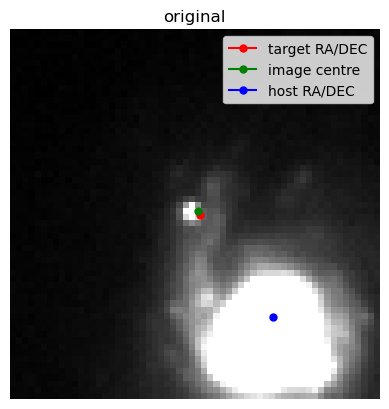

<Figure size 500x500 with 0 Axes>

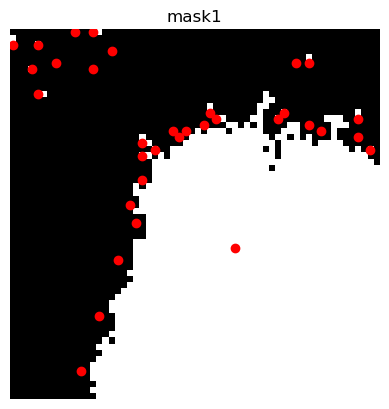

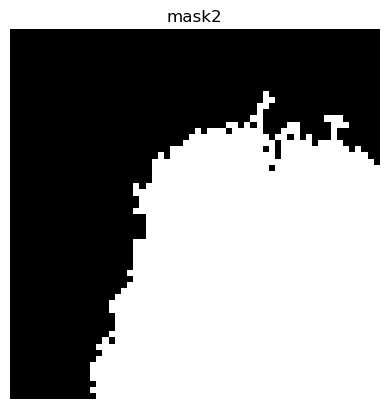

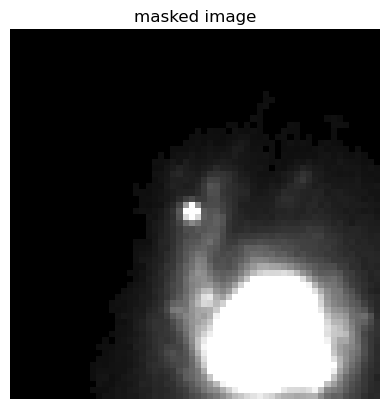

host pixel:  [42.28082051154447, 12.859775845123693]


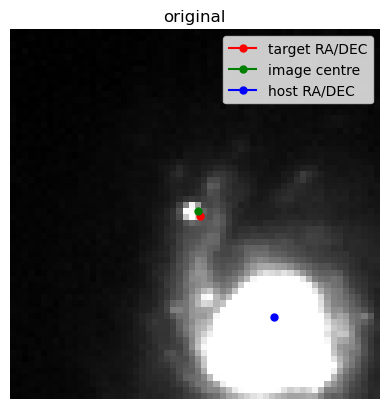

<Figure size 500x500 with 0 Axes>

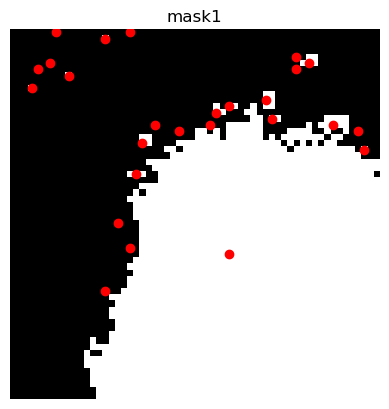

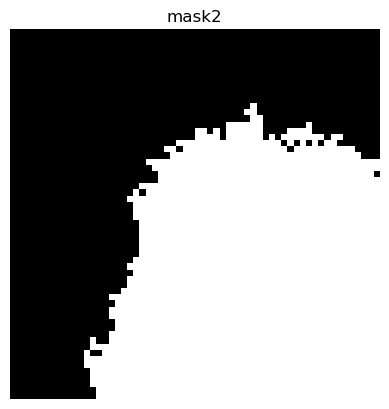

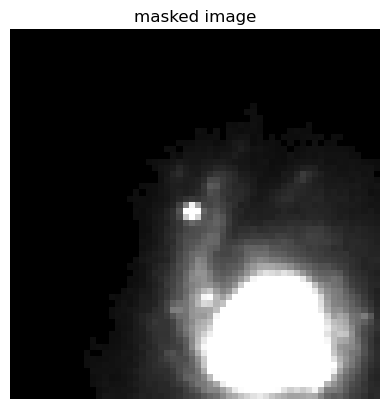

host pixel:  [41.95195380351841, 12.019995372515382]


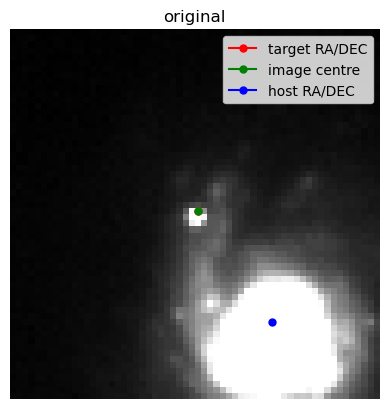

<Figure size 500x500 with 0 Axes>

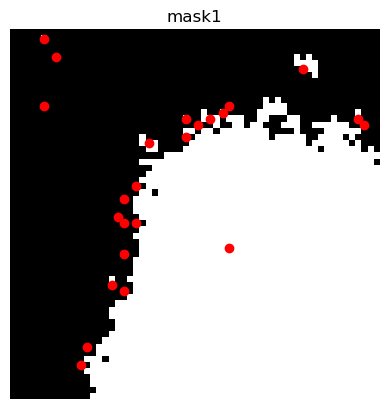

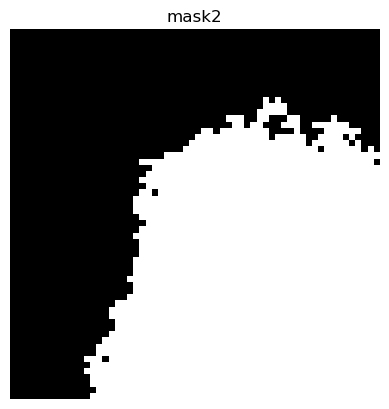

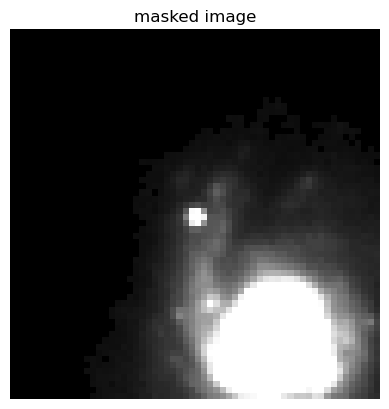

host pixel:  [41.53323244314474, 12.483114459281353]


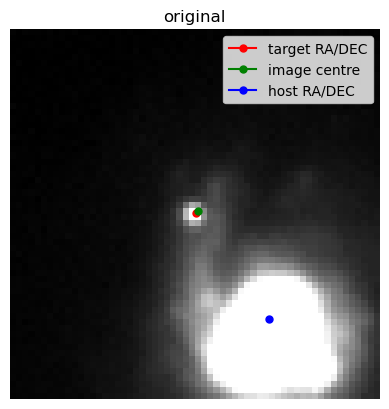

<Figure size 500x500 with 0 Axes>

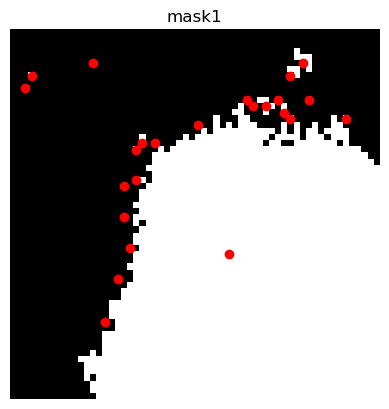

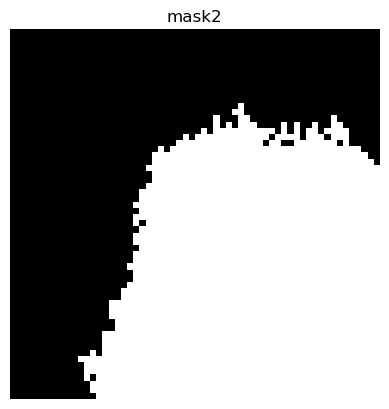

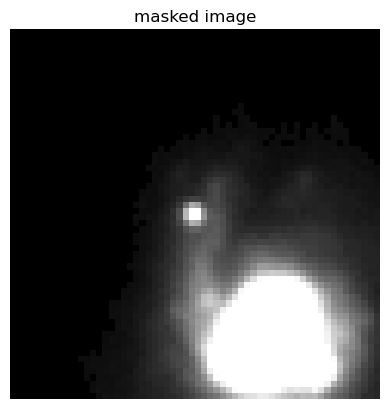

In [5]:
host_path = '/Users/xinyuesheng/Documents/astro_projects/data/host_info_r5/'
target_path = '/Users/xinyuesheng/Documents/astro_projects/data/mag_sets_v4/'
img_file = '/Users/xinyuesheng/Documents/astro_projects/data/image_sets_v3/'
ztf_obj = 'ZTF21aaqgmjt'
target_ra, target_dec = get_target_coords(target_path + ztf_obj + '.json')
host_ra, host_dec = get_host_coords(host_path + ztf_obj + '.csv')

print(f'host coords: {host_ra}, {host_dec}, transient_coords: {target_ra}, {target_dec}')
r_detections_with_mags = get_detection_with_mag(img_file + ztf_obj + '/image_meta.json')

# plot detection images which have corresponding magnitude records
for d in r_detections_with_mags:
    detection_path = img_file + ztf_obj + '/2/' + d
    for dirpath, dirnames, filenames in os.walk(detection_path):
        for f in filenames:
            if f.startswith('sci_'):
                map_coordinate_with_pixel(os.path.join(dirpath, f), target_ra, target_dec, host_ra, host_dec, image_type = 'd')
           
                
       
           


In [3]:
# plot reference image
for dirpath, dirnames, filenames in os.walk(img_file + ztf_obj + '/2/'):
    for f in filenames:
        if f.startswith('ref_'):
            try:
                map_coordinate_with_pixel(os.path.join(dirpath, f), target_ra, target_dec, host_ra, host_dec, label = 'r')
            except:
                continue

1. check the accuracy between the object coords and detection coords; tolerance 2-3 degrees

2. check object ZTF18aaqqhis, last detection with mag - the image is not complete - lead to wrong host pixels.